### ***Loan Delinquent Analysis***

#### ***Context***

DRS bank is facing challenging times. Their NPAs (Non-Performing Assets) have been on a rise recently and a large part of these are due to the loans given to individual customers(borrowers). The Chief Risk Officer of the bank decides to put in a scientifically robust framework for approval of loans to individual customers to minimize the risk of loans converting into NPAs and initiates a project for the data science team at the bank. You, as a senior member of the team, are assigned this project.

#### ***Objective***
To identify the criteria to approve loans for an individual customer such that the likelihood of the loan delinquency is minimized

#### ***Key questions to be answered***
What are the factors that drive the behavior of loan delinquency?

#### ***Data Description***
* `ID`: Customer ID
* `isDelinquent` : indicates whether the customer is delinquent or not (1 => Yes, 0 => No)
* `term`: Loan term in months
* `gender`: Gender of the borrower
* `age`: Age of the borrower
* `purpose`: Purpose of Loan
* `home_ownership`: Status of borrower's home
* `FICO`: FICO (i.e. the bureau score) of the borrower

#### ***Domain Information*** 
Transactor – A person who pays his due amount balance full and on time.<br>
Revolver – A person who pays the minimum due amount but keeps revolving his balance and does not pay the full amount.<br>
Delinquent - Delinquency means that you are behind on payments, a person who fails to pay even the minimum due amount.<br>
Defaulter – Once you are delinquent for a certain period your lender will declare you to be in the default stage.<br>
Risk Analytics – A wide domain in the financial and banking industry, basically analyzing the risk of the customer.<br>

#### ***Import Libraries***

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores and split data
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
)

# To build a logistic regression model
from sklearn.linear_model import LogisticRegression

# To use statistical functions
import scipy.stats as stats

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To suppress the warning
import warnings

warnings.filterwarnings("ignore")

#### ***Dataset Load and Overview***

In [2]:
data = pd.read_csv("data/21_Loan_Delinquent_Dataset.csv")

In [3]:
# copying data to another varaible to avoid any changes to original data
loan = data.copy()

In [4]:
# Checking the number of rows and columns in the data
data.shape

(11548, 8)

In [5]:
# let's check the data types of the columns in the dataset
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11548 entries, 0 to 11547
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              11548 non-null  int64 
 1   isDelinquent    11548 non-null  int64 
 2   term            11548 non-null  object
 3   gender          11548 non-null  object
 4   purpose         11548 non-null  object
 5   home_ownership  11548 non-null  object
 6   age             11548 non-null  object
 7   FICO            11548 non-null  object
dtypes: int64(2), object(6)
memory usage: 721.9+ KB


In [6]:
# let's view a random sample of 10 rows from the data
loan.sample(10)

,ID,isDelinquent,term,gender,purpose,home_ownership,age,FICO
4038,4039,1,36 months,Male,House,Own,20-25,300-500
11505,11506,1,36 months,Male,Car,Rent,20-25,300-500
4455,4456,0,36 months,Female,House,Mortgage,>25,>500
4792,4793,1,36 months,Female,House,Rent,20-25,300-500
7205,7206,0,36 months,Female,Personal,Mortgage,20-25,>500
1514,1515,1,36 months,Male,House,Rent,20-25,300-500
4957,4958,1,36 months,Female,Personal,Mortgage,>25,300-500
6236,6237,1,36 months,Female,House,Mortgage,>25,300-500
8476,8477,1,36 months,Female,Personal,Mortgage,>25,300-500
3575,3576,1,36 months,Male,House,Mortgage,>25,>500


***Observations***

- *`ID` this is sequence id, can be removed*
- *`isDelinquent` is the boolean Target Variable*
- *`term` we have to find out how many unique values are there*
- *`age` is given as range*
- *`FICO` is give as range*

***All Dependent variable are given as object, converting them to category***

In [7]:
loan["term"] = loan["term"].astype("category")
loan["gender"] = loan["gender"].astype("category")
loan["purpose"] = loan["purpose"].astype("category")
loan["home_ownership"] = loan["home_ownership"].astype("category")
loan["age"] = loan["age"].astype("category")
loan["FICO"] = loan["FICO"].astype("category")
loan["isDelinquent"] = loan["isDelinquent"].astype("category")

In [8]:
loan.drop(["ID"], axis=1, inplace=True)

In [9]:
# let's check for duplicate values in the data
loan.duplicated().sum()

np.int64(11271)

In [10]:
# let's check for missing values in the data
loan.isnull().sum()

isDelinquent      0
term              0
gender            0
purpose           0
home_ownership    0
age               0
FICO              0
dtype: int64

- There are no missing values in the data

In [11]:
# let's view the statistical summary of the numerical columns in the data
loan.describe(include="all")

,isDelinquent,term,gender,purpose,home_ownership,age,FICO
count,11548,11548,11548,11548,11548,11548,11548
unique,2,2,2,7,3,2,2
top,1,36 months,Male,House,Mortgage,20-25,300-500
freq,7721,10589,6555,6892,5461,5888,6370


***Observations***

* *Most of the customers are loan delinquent(1)*
* *Most of the loans are for a 36-month term loan*
* *More males have applied for loans than females*
* *Most loan applications are for house loans*
* *Most customers have either mortgaged their houses*
* *Mostly customers in the age group 20-25 have applied for a loan*
* *Most customers have a FICO score between 300 and 500*

In [12]:
# checking unique value in purpose
loan["purpose"].unique()

['House', 'Car', 'Other', 'Personal', 'Wedding', 'Medical', 'other']
Categories (7, object): ['Car', 'House', 'Medical', 'Other', 'Personal', 'Wedding', 'other']

In [13]:
# We can merge the purpose -  'other' and 'Other' together
loan["purpose"].replace("other", "Other", inplace=True)

In [14]:
loan["purpose"].unique()

['House', 'Car', 'Other', 'Personal', 'Wedding', 'Medical']
Categories (6, object): ['Car', 'House', 'Medical', 'Other', 'Personal', 'Wedding']

### ***Exploratory Data Analysis***

***Helper Function***

In [15]:
def target_distribution_by_category(data, x_col, hue_col, colormap='tab20', figsize=(6, 4), title=None):
    """
    Plots a stacked bar chart showing percentage distribution of hue_col within each x_col category,
    with percentage labels on each segment.
    """
    # Group and calculate percentages
    grouped = data.groupby([x_col, hue_col]).size().unstack(fill_value=0)
    percentages = grouped.div(grouped.sum(axis=1), axis=0) * 100

    # Plot
    ax = percentages.plot(kind='bar', stacked=True, figsize=figsize, colormap=colormap)

    # Add percentage labels
    for i, (index, row) in enumerate(percentages.iterrows()):
        cum_height = 0
        for j, value in enumerate(row):
            if value > 0:
                ax.text(
                    i,                      # x position
                    cum_height + value / 2, # y position (middle of the bar segment)
                    f'{value:.1f}%',        # label text
                    ha='center', va='center', fontsize=8, color='white'
                )
                cum_height += value

    plt.ylabel('Percentage')
    plt.title(title or f'{x_col} Distribution by {hue_col} (Stacked Percentage)')
    plt.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


***Delinquency by Loan Term***

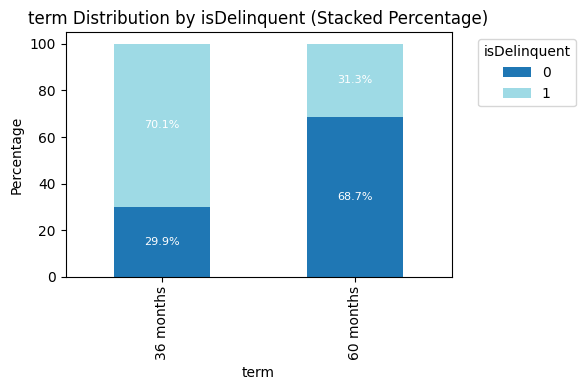

In [16]:
target_distribution_by_category(loan, 'term', 'isDelinquent')

*36 months loan tennure has higher percentage of delinquints*

***Delinquency by Gender***

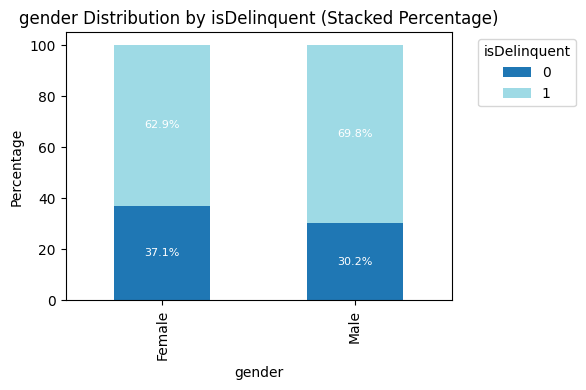

In [17]:
target_distribution_by_category(loan, 'gender', 'isDelinquent')

*Males have higher percentage of delinquency*

***Home Ownership vs Delinquency***

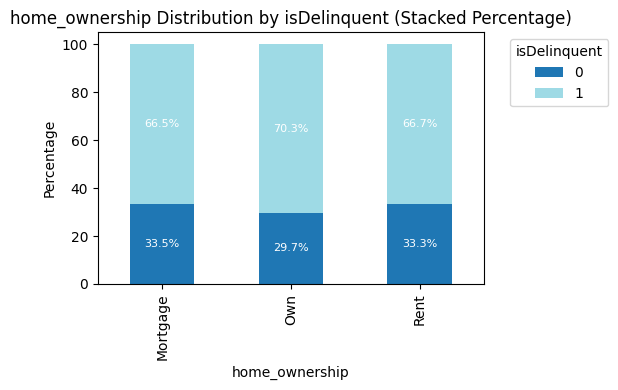

In [18]:
target_distribution_by_category(loan, 'home_ownership', 'isDelinquent')

*Surprisingly folks who own houses, have higher percentage of delinquency compared to mortgage and rent*

***Purpose vs Delinquency***

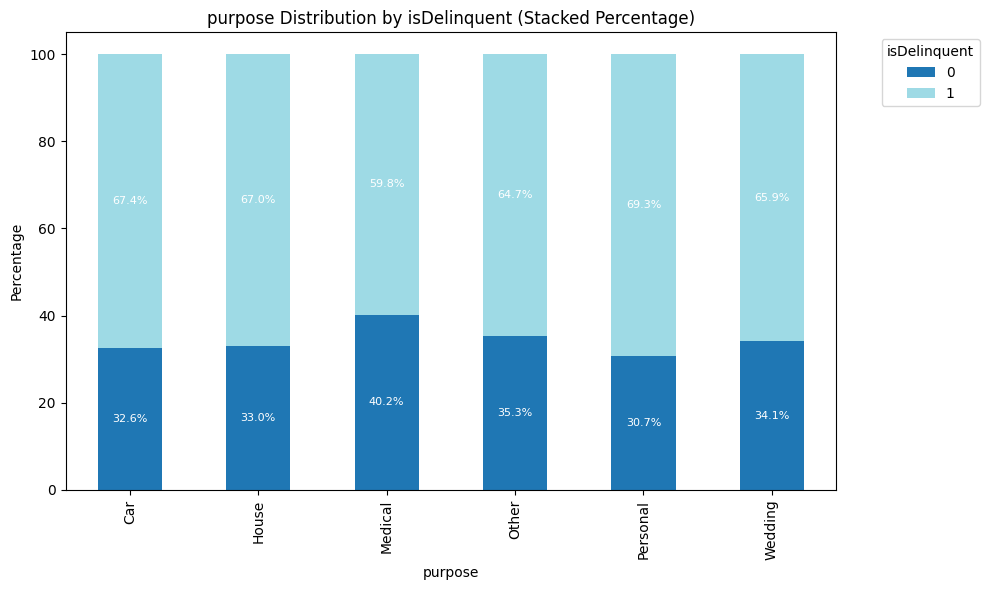

In [19]:
target_distribution_by_category(loan, 'purpose', 'isDelinquent',figsize=(10, 6))

*Most of the delinquency is from Personal Loans, then House and Car*

***Age vs Delinquency***

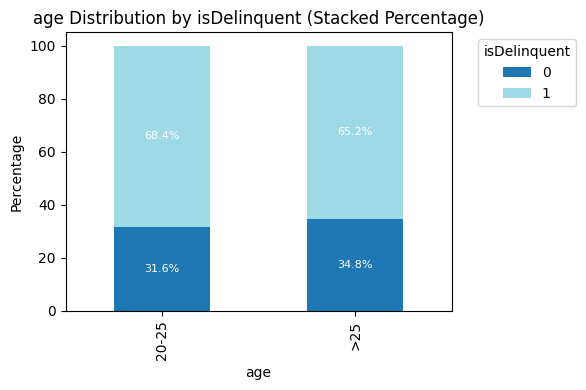

In [20]:
target_distribution_by_category(loan, 'age', 'isDelinquent')

*There is higher percentage if delinquency amount 20-25 age group compared to >25 group*

***FICO vs Delinquency***

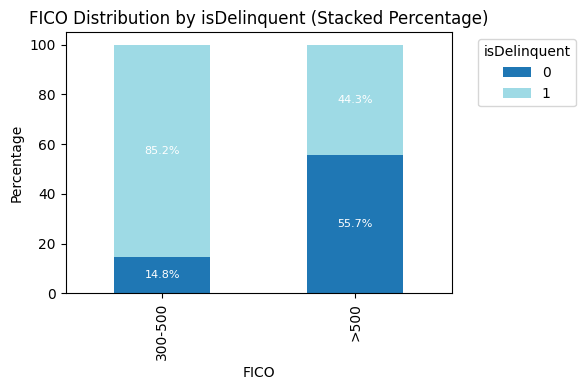

In [21]:
target_distribution_by_category(loan, 'FICO', 'isDelinquent')

*People with lower FICO score have higher chance of delinquency*

### ***Data Preparation for Modeling***

In [22]:
x = loan.drop(["isDelinquent"], axis=1)
y = loan["isDelinquent"]

In [23]:
# encoding the categorical variables
x = pd.get_dummies(x, drop_first=True)

#### ***Data Split into Training, Validation and Test set: In 2 steps***

- ***First Split the data into `Temp` and `Test`***
- ***Then Split the `Temp` into `Train` and `Val`***

In [24]:
# first we split data into 2 parts, say temporary and test
X_temp, X_test, y_temp, y_test = train_test_split(x, y, test_size=0.2, random_state=1, stratify=y)

# then we split the temporary set into train and validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp)

X_train = X_train.astype({col: int for col in X_train.select_dtypes(include='bool').columns})

print(X_train.shape, X_val.shape, X_test.shape)

(6928, 11) (2310, 11) (2310, 11)


In [25]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in validation data =", X_val.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 6928
Number of rows in validation data = 2310
Number of rows in test data = 2310


### ***Model Building***

#### ***Model evaluation criterion:***

***Model can make wrong predictions as:***

- ***Predicting a customer will not be behind on payments (Non-Delinquent) but in reality the customer would be behind on payments. False Negative. Model misses Risky Customer, leading to financial loss. This is often considered more costly.***

- ***Predicting a customer will be behind on payments (Delinquent) but in reality the customer would not be behind on payments (Non-Delinquent). False Positive
How to reduce this loss i.e need to reduce False Negatives?***

***Recall should be maximized, the greater the recall higher the chances of minimizing the false negatives.***

In [26]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [27]:
def confusion_matrix_sklearn(model, predictors, y_actual):
    """
    Generates a labeled confusion matrix heatmap.

    Parameters:
    - model: trained classifier
    - predictors: feature matrix to predict on (can be train, test, or validation)
    - y_actual: true labels corresponding to X
    """
    # Predict labels
    y_predict = model.predict(predictors)

    # Compute confusion matrix
    cm = confusion_matrix(y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index=["Actual - No", "Actual - Yes"],
                             columns=["Predicted - No", "Predicted - Yes"])

    # Annotate with counts and percentages
    group_counts = [f"{value:0.0f}" for value in cm.flatten()]
    group_percentages = [f"{value:.2%}" for value in cm.flatten() / np.sum(cm)]
    labels = [f"{count}\n{percent}" for count, percent in zip(group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(cm.shape)

    # Plot heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(df_cm, annot=labels, fmt='', cmap='Blues')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

#### ***Logistic Regression***

***Let's evaluate the model performance by using KFold and cross_val_score***

- ***`K-Folds cross-validation` provides dataset indices to split data into train/validation sets. Split dataset into k consecutive stratified folds (without shuffling by default). Each fold is then used once as validation while the k - 1 remaining folds form the training set.***

In [28]:
lr = LogisticRegression(random_state=1)
lr.fit(X_train, y_train)

scoring = "recall"

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)  # Setting number of splits equal to 5

cv_recall_array = cross_val_score(estimator=lr, X=X_train, y=y_train, scoring=scoring, cv=kfold) # 

# print the recall mean and standard deviation for the cross-validation scores
print(f"Cross-Validation Recall Scores: {cv_recall_array}")
print(f"Mean Recall Score: {round(np.mean(cv_recall_array), 3)}")
print(f"Standard Deviation of Recall Scores: {round(np.std(cv_recall_array), 3)}")

Cross-Validation Recall Scores: [0.8781014  0.86299892 0.86177106 0.88984881 0.87904968]
Mean Recall Score: 0.874
Standard Deviation of Recall Scores: 0.011


* ***Mean Recall score is 0.874.***

In [29]:
# Calculating different metrics on train set
log_reg_model_train_perf = model_performance_classification_sklearn(lr, X_train, y_train)

print("Training performance:")
log_reg_model_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.782621,0.872409,0.815375,0.842929


In [30]:
# Calculating different metrics on validation set
log_reg_model_val_perf = model_performance_classification_sklearn(lr, X_val, y_val)

print("Validation performance:")
log_reg_model_val_perf

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.797403,0.891909,0.820727,0.854839


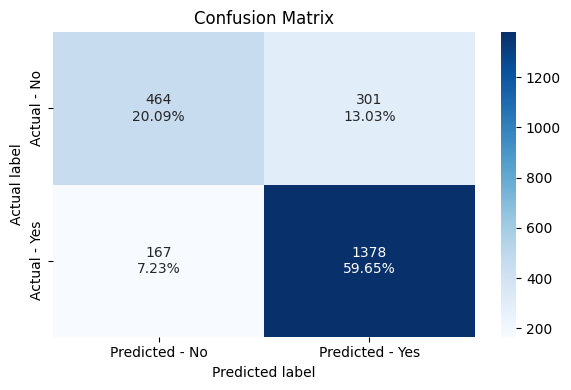

In [31]:
# creating confusion matrix
confusion_matrix_sklearn(lr, X_val, y_val)

* ***Logistic Regression has given a generalized performance on training and validation set.***
* ***Let's try oversampling (increase training data) to see if the model performance can be improved.***

#### ***`Oversampling` training data using `SMOTE`***

In [32]:
print("Before UpSampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before UpSampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)  # Oversample minority class to have the same number of samples as majority class

X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

print("After UpSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After UpSampling, the shape of train_y: {} \n".format(y_train_over.shape))

print("After UpSampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After UpSampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))

Before UpSampling, counts of label 'Yes': 4632
Before UpSampling, counts of label 'No': 2296 

After UpSampling, the shape of train_X: (9264, 11)
After UpSampling, the shape of train_y: (9264,) 

After UpSampling, counts of label 'Yes': 4632
After UpSampling, counts of label 'No': 4632 



#### ***Logistic Regression on oversampled data***

In [33]:
log_reg_over = LogisticRegression(random_state=1)

# Training the basic logistic regression model with training set
log_reg_over.fit(X_train_over, y_train_over)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


***Let's evaluate the model performance by using KFold and cross_val_score***

- *`K-Folds cross-validation` provides dataset indices to split data into train/validation sets. Split dataset into k consecutive stratified folds (without shuffling by default). Each fold is then used once as validation while the k - 1 remaining folds form the training set.*

In [34]:
scoring = "recall"
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)  # Setting number of splits equal to 5

cv_result_over = cross_val_score(estimator=log_reg_over, X=X_train_over, y=y_train_over, scoring=scoring, cv=kfold)  # Cross-validation scores

# print the recall mean and standard deviation for the cross-validation scores
print(f"Cross-Validation Recall Scores: {cv_result_over}")
print(f"Mean Recall Score: {round(np.mean(cv_result_over), 3)}")
print(f"Standard Deviation of Recall Scores: {round(np.std(cv_result_over), 3)}\n")

Cross-Validation Recall Scores: [0.77454153 0.7605178  0.74730022 0.80453564 0.78185745]
Mean Recall Score: 0.774
Standard Deviation of Recall Scores: 0.019



* *Mean recall score is 0.774, which is less than previous recall score when used without oversampling*
* *Let's check the performance on Validation set*

In [35]:
# Calculating different metrics on train set
log_reg_over_train_perf = model_performance_classification_sklearn(log_reg_over, X_train_over, y_train_over)

print("Training performance:")
log_reg_over_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.790263,0.771805,0.80139,0.786319


In [36]:
# Calculating different metrics on validation set
log_reg_over_val_perf = model_performance_classification_sklearn(log_reg_over, X_val, y_val)

print("validation performance:")
log_reg_over_val_perf

validation performance:


,Accuracy,Recall,Precision,F1
0,0.793939,0.792233,0.8876,0.837209


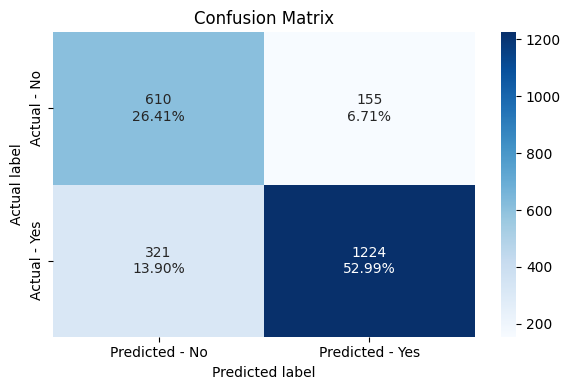

In [37]:
# creating confusion matrix
confusion_matrix_sklearn(log_reg_over, X_val, y_val)

***I have interesting observation. Oversampling of minority class didn't improve the recall score***

#### ***Regularization***

In [38]:
# Choose the type of classifier.
lr_estimator = LogisticRegression(random_state=1, solver="saga") # Using 'saga' solver as it supports both L1 and L2 regularization and is suitable for large datasets.

# Grid of parameters to choose from
parameters = {"C": np.arange(0.1, 1.1, 0.1)} # Regularization strength parameter grid for Logistic Regression to be used in GridSearchCV
                                             # C is the inverse of regularization strength; smaller values specify stronger regularization.

# Run the grid search
grid_obj = GridSearchCV(lr_estimator, parameters, scoring="recall")
grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
lr_estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
lr_estimator.fit(X_train_over, y_train_over)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,np.float64(1.0)
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


In [39]:
# Calculating different metrics on train set
log_reg_reg_train_perf = model_performance_classification_sklearn(lr_estimator, X_train_over, y_train_over)

print("Training performance:")
log_reg_reg_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.791235,0.771805,0.80301,0.787098


In [40]:
# Calculating different metrics on validation set
log_reg_reg_val_perf = model_performance_classification_sklearn(lr_estimator, X_val, y_val)

print("Validation performance:")
log_reg_reg_val_perf

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.794372,0.792233,0.888244,0.837496


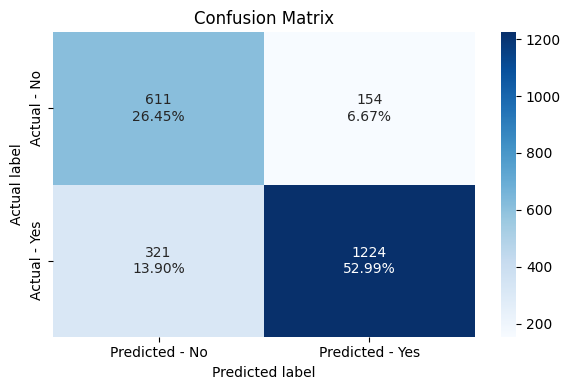

In [41]:
# creating confusion matrix
confusion_matrix_sklearn(lr_estimator, X_val, y_val)

***Regularization and Oversampling has given similar recall scores in training and validation sets***

#### ***Undersampling train data using RandomUnderSampler***

In [42]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [43]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 4632
Before Under Sampling, counts of label 'No': 2296 

After Under Sampling, counts of label 'Yes': 2296
After Under Sampling, counts of label 'No': 2296 

After Under Sampling, the shape of train_X: (4592, 11)
After Under Sampling, the shape of train_y: (4592,) 



#### ***Logistic Regression on undersampled data***

In [44]:
log_reg_under = LogisticRegression(random_state=1)
log_reg_under.fit(X_train_un, y_train_un)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


***Let's evaluate the model performance by using KFold and cross_val_score***

- *`K-Folds cross-validation` provides dataset indices to split data into train/validation sets. Split dataset into k consecutive stratified folds (without shuffling by default). Each fold is then used once as validation while the k - 1 remaining folds form the training set.*

In [45]:
scoring = "recall"
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)  # Setting number of splits equal to 5

cv_result_under = cross_val_score(estimator=log_reg_under, X=X_train_un, y=y_train_un, scoring=scoring, cv=kfold
)

# print the recall mean and standard deviation for the cross-validation scores
print(f"Cross-Validation Recall Scores: {cv_result_under}")
print(f"Mean Recall Score: {round(np.mean(cv_result_under), 3)}")
print(f"Standard Deviation of Recall Scores: {round(np.std(cv_result_under), 3)}")


Cross-Validation Recall Scores: [0.77342048 0.68913043 0.69281046 0.71895425 0.708061  ]
Mean Recall Score: 0.716
Standard Deviation of Recall Scores: 0.03


***Mean Recall score is 0.716***

In [46]:
# Calculating different metrics on train set
log_reg_under_train_perf = model_performance_classification_sklearn(log_reg_under, X_train_un, y_train_un)

print("Training performance:")
log_reg_under_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.768075,0.708624,0.804251,0.753415


In [47]:
# Calculating different metrics on validation set
log_reg_under_val_perf = model_performance_classification_sklearn(log_reg_under, X_val, y_val)

print("Validation performance:")
log_reg_under_val_perf

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.769264,0.739806,0.897174,0.810926


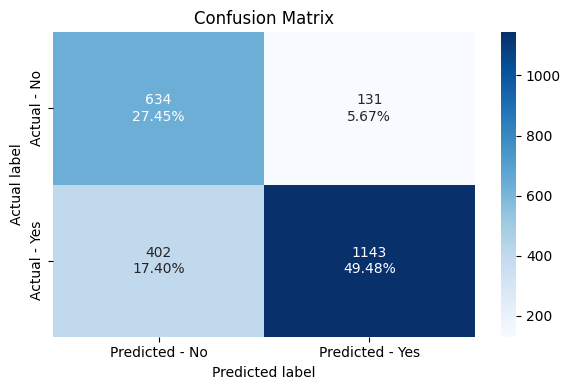

In [48]:
# creating confusion matrix
confusion_matrix_sklearn(log_reg_under, X_val, y_val)

***Recall has increased for validation set but overall recall is lower than logistic regression and oversampling***

In [49]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        log_reg_model_train_perf.T,
        log_reg_over_train_perf.T,
        log_reg_reg_train_perf.T,
        log_reg_under_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression",
    "Logistic Regression with oversampled data",
    "Regularised Logistic Regression",
    "Logistic Regression with undersampled data",
]
print("Training performance comparison:")
models_train_comp_df.T

Training performance comparison:


,Accuracy,Recall,Precision,F1
Logistic Regression,0.782621,0.872409,0.815375,0.842929
Logistic Regression with oversampled data,0.790263,0.771805,0.801390,0.786319
Regularised Logistic Regression,0.791235,0.771805,0.803010,0.787098
Logistic Regression with undersampled data,0.768075,0.708624,0.804251,0.753415


In [50]:
# Validation performance comparison

models_train_comp_df = pd.concat(
    [
        log_reg_model_val_perf.T,
        log_reg_over_val_perf.T,
        log_reg_reg_val_perf.T,
        log_reg_under_val_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression",
    "Logistic Regression with oversampled data",
    "Regularised Logistic Regression",
    "Logistic Regression with undersampled data",
]
print("Validation performance comparison:")
models_train_comp_df.T

Validation performance comparison:


,Accuracy,Recall,Precision,F1
Logistic Regression,0.797403,0.891909,0.820727,0.854839
Logistic Regression with oversampled data,0.793939,0.792233,0.887600,0.837209
Regularised Logistic Regression,0.794372,0.792233,0.888244,0.837496
Logistic Regression with undersampled data,0.769264,0.739806,0.897174,0.810926


#### ***We can see that first model is the best, let's check the performance of test data***

In [51]:
# Calculating different metrics on validation set
log_reg_model_test_perf = model_performance_classification_sklearn(lr, X_test, y_test)

print("Test performance:")
log_reg_model_test_perf

Test performance:


,Accuracy,Recall,Precision,F1
0,0.789177,0.88342,0.816278,0.848523


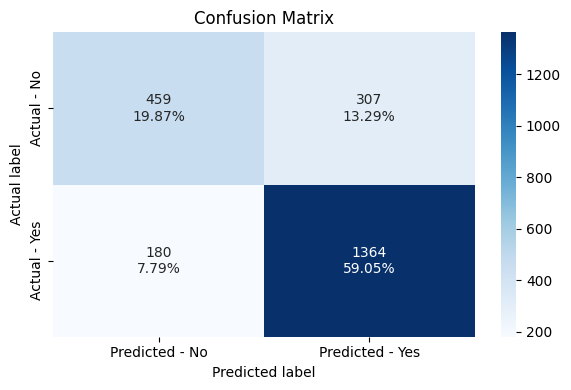

In [52]:
# creating confusion matrix
confusion_matrix_sklearn(lr, X_test, y_test)

***Logistic Regression has given better Recall compared to Oversampling, Undersampling and Regularlization***